# Visualising datasets

## 0.1. Imports and load data

In [1]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester, extract_latent_space
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)

MAX_EPOCHS = 10
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)



ModuleNotFoundError: No module named 'mace.data.atom_data_loader'

In [3]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = 3731  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = 3731 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 3731
transfer_atoms_list length: 3731


## 0.2. Split into test, train, valid sets

In [4]:
# get bond lengths and dihedrals
# tested on propene only

desc_matrix = []
bond_lengths = []
dihedrals = []

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths",atom)[0]
    dihedral = descriptors.get_descriptor("dihedral",atom)[0]
    
    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)
    desc_matrix.append([bond_length, dihedral])

desc_matrix = np.asarray(desc_matrix)

# extract test set
# the same test set is removed from both base and transfer datasets

TEST_SET_FRACTION = 0.1
TEST_SET_SIZE = int(np.floor(int(BASE_N_GEOMETRIES) * TEST_SET_FRACTION))

test_set_idx = selectors.get_selector("uniform_grid", desc_matrix, TEST_SET_SIZE)
base_test_set = [base_atoms_list[i] for i in test_set_idx]
transfer_test_set = [transfer_atoms_list[i] for i in test_set_idx]
print("Test set size:", len(base_test_set))

# remaining geometries are for training and validation
train_valid_set_idx = np.setdiff1d(np.arange(len(transfer_atoms_list)), test_set_idx)
base_train_valid_set = [base_atoms_list[i] for i in train_valid_set_idx]
transfer_train_valid_set = [transfer_atoms_list[i] for i in train_valid_set_idx]

# split remaining geometries into train and valid sets
# the same for both base and transfer datasets

SEED = 42 # set as int to get the same split every time
VALID_SET_FRACTION = 0.1 # as a fraction of the total dataset

train_set_idx, valid_set_idx = train_test_split(
    train_valid_set_idx, test_size=VALID_SET_FRACTION/(1-TEST_SET_FRACTION), random_state=SEED, shuffle=True
)

base_train_set = [base_atoms_list[i] for i in train_set_idx]
print("\nBase train set size:", len(base_train_set))
base_valid_set = [base_atoms_list[i] for i in valid_set_idx]
print("Base valid set size:", len(base_valid_set))

transfer_train_set = [transfer_atoms_list[i] for i in train_set_idx]
print("\nFull high-fidelity train set size:", len(transfer_train_set))
transfer_valid_set = [transfer_atoms_list[i] for i in valid_set_idx]
print("Full high-fidelity valid set size:", len(transfer_valid_set))


Test set size: 361

Base train set size: 2995
Base valid set size: 375

Full high-fidelity train set size: 2995
Full high-fidelity valid set size: 375


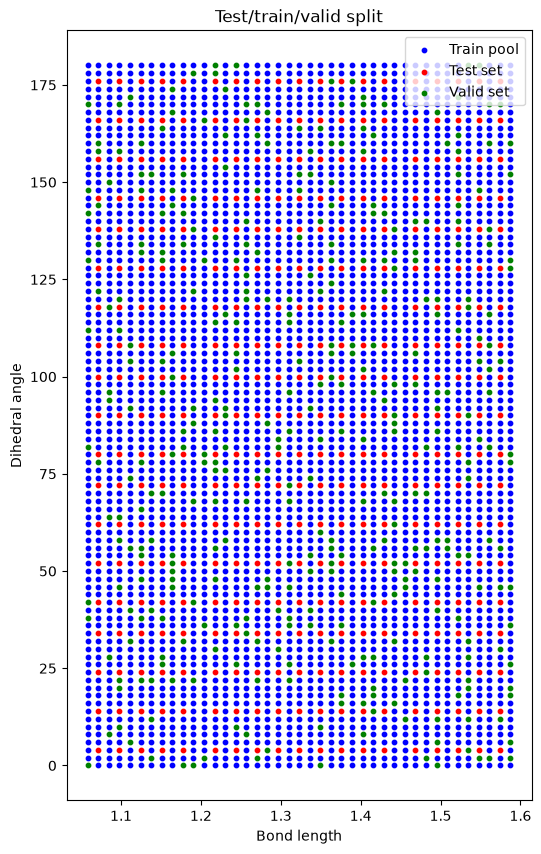

In [5]:
# visualise
%matplotlib inline

plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, label='Train pool')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, label='Test set')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, label='Valid set')

plt.title("Test/train/valid split")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 0.3. Descriptor

In [27]:
# load base model, full model

base_model_filename = "base_model_propene_3731_geometries.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
base_model = torch.load(base_model_save_path, weights_only=False)

base_model.eval()

base_encoder = base_model.perm_encoder

full_model_filename = "full_model_propene_3731_geometries.pt"
full_model_save_path = OUTPUT_DIR / "full_models" / full_model_filename
full_model = torch.load(full_model_save_path, weights_only=False)

full_model.eval()

AutoencoderExcitedMACE(
  (node_embedding): LinearNodeEmbeddingBlock(
    (linear): Linear(2x0e -> 4x0e | 8 weights)
  )
  (radial_embedding): RadialEmbeddingBlock(
    (bessel_fn): BesselBasis(r_max=5.0, num_basis=4, trainable=False)
    (cutoff_fn): PolynomialCutoff(p=3.0, r_max=5.0)
  )
  (perm_encoder): PermutationInvariantEncoder(
    (elementwise_nn): Sequential(
      (0): Linear(in_features=1, out_features=16, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=16, out_features=16, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=16, out_features=16, bias=True)
      (7): ELU(alpha=1.0)
    )
    (post_aggregation_nn): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=16, out_features=16, bias=

In [ ]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "dihedral", "energies", "encoded_energies", "soap", "acsf", "mbtr", "latent_space"]
DESCRIPTOR = DESCRIPTOR_TYPE[8]  # choose the descriptor type to use

# matrix of descriptors for each geometry
# sampling is done on base dataset, out of the training pool only
# ie test and valid sets are already removed
desc_matrix = []
if DESCRIPTOR == "latent_space":
    base_train_loader_unshuffle = data_builder.load(
        base_train_set, batch_size=BATCH_SIZE, shuffle=False
    )
    train_latent_space = extract_latent_space(
        base_model, base_train_loader_unshuffle, device=DEVICE
    )
    desc_matrix = train_latent_space
else:
    for atom in base_train_set:
        desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)


desc_matrix shape: (2995, 16)
desc_matrix unique shape: (2995, 16)
desc_matrix:
 [[-1.2087054   0.11680095 -0.5589149  ... -1.3300848   1.7829703
   0.90153855]
 [-1.1781795   0.1718116  -0.5746635  ... -1.3111407   1.8391098
   0.87157404]
 [-1.1917729   0.29069722 -0.6382212  ... -1.2045417   1.9290845
   0.7771661 ]
 ...
 [-1.1842715   0.14935547 -0.5658525  ... -1.3272974   1.8163601
   0.88567406]
 [-1.1548558   0.20012794 -0.58014446 ... -1.2892287   1.8898118
   0.8643158 ]
 [-1.179636    0.11040239 -0.545122   ... -1.3495538   1.801417
   0.92102194]]


In [ ]:
# get desc vectors for the test and valid sets as well

test_desc_matrix = []
valid_desc_matrix = []
if DESCRIPTOR == "latent_space":
    base_test_loader_unshuffle = data_builder.load(
        base_test_set, batch_size=BATCH_SIZE, shuffle=False
    )
    test_latent_space = extract_latent_space(
        base_model, base_test_loader_unshuffle, device=DEVICE
    )
    test_desc_matrix = test_latent_space

    base_valid_loader_unshuffle = data_builder.load(
        base_valid_set, batch_size=BATCH_SIZE, shuffle=False
    )
    valid_latent_space = extract_latent_space(
        base_model, base_valid_loader_unshuffle, device=DEVICE
    )
    valid_desc_matrix = valid_latent_space
else:
    for atom in base_test_set:
        test_desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    test_desc_matrix = np.asarray(desc_matrix)

    for atom in base_valid_set:
        valid_desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    valid_desc_matrix = np.asarray(desc_matrix)

print("test_desc_matrix shape:", test_desc_matrix.shape)
print("test_desc_matrix unique shape:", np.unique(test_desc_matrix, axis=0).shape)
print("test_desc_matrix:\n", test_desc_matrix)

print("\nvalid_desc_matrix shape:", valid_desc_matrix.shape)
print("valid_desc_matrix unique shape:", np.unique(valid_desc_matrix, axis=0).shape)
print("valid_desc_matrix:\n", valid_desc_matrix)

test_desc_matrix shape: (361, 16)
test_desc_matrix unique shape: (361, 16)
test_desc_matrix:
 [[-1.1955875   0.37429562 -0.68092173 ... -1.1248734   2.0064528
   0.71666646]
 [-1.1977904   0.37588707 -0.682504   ... -1.1230462   2.0052843
   0.71415216]
 [-1.2022622   0.37914622 -0.6857292  ... -1.1193557   2.0028791
   0.7090083 ]
 ...
 [-1.2149435   0.11322843 -0.5595102  ... -1.3224487   1.7820091
   0.9029384 ]
 [-1.2139695   0.11239144 -0.55874586 ... -1.3231355   1.7825608
   0.9041743 ]
 [-1.2134229   0.11192884 -0.55832046 ... -1.323524    1.7828687
   0.90486103]]

valid_desc_matrix shape: (375, 16)
valid_desc_matrix unique shape: (375, 16)
valid_desc_matrix:
 [[-1.2011967   0.1207682  -0.55807394 ... -1.335286    1.7878163
   0.90115565]
 [-1.2017751   0.39725173 -0.69450694 ... -1.1021404   2.0215664
   0.6968576 ]
 [-1.1874938   0.12371135 -0.55448246 ... -1.3412611   1.7993425
   0.90524936]
 ...
 [-1.1825999   0.15418749 -0.5676137  ... -1.3241768   1.82133
   0.8827539 ]

In [28]:
# get desc vectors for the full (high-fidelity) dataset as well

full_desc_matrix = []
if DESCRIPTOR == "latent_space":
    full_train_loader_unshuffle = data_builder.load(
        transfer_train_set, batch_size=BATCH_SIZE, shuffle=False
    )
    full_latent_space = extract_latent_space(
        full_model, full_train_loader_unshuffle, device=DEVICE
    )
    full_desc_matrix = full_latent_space

else:
    for atom in transfer_train_set:
        full_desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    full_desc_matrix = np.asarray(desc_matrix)

print("full_desc_matrix shape:", full_desc_matrix.shape)
print("full_desc_matrix unique shape:", np.unique(full_desc_matrix, axis=0).shape)
print("full_desc_matrix:\n", full_desc_matrix)

full_desc_matrix shape: (2995, 16)
full_desc_matrix unique shape: (2995, 16)
full_desc_matrix:
 [[-1.3279651   0.07724133 -0.54707545 ... -1.1445769   1.3535807
   0.8615856 ]
 [-1.3107799   0.1294455  -0.56737036 ... -1.1594243   1.3660119
   0.81733894]
 [-1.3513125   0.24077891 -0.63761187 ... -1.1106573   1.3811455
   0.70203614]
 ...
 [-1.3051718   0.10645837 -0.5538208  ... -1.1650164   1.3656855
   0.84167886]
 [-1.32845     0.16730025 -0.5926375  ... -1.1427999   1.3619604
   0.7735697 ]
 [-1.3133224   0.07793178 -0.5423068  ... -1.1596975   1.3557528
   0.86483234]]


## 0.4. Selector

In [13]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "k_means_clustering_weighted", "birch", "birch_weighted", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[3]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES, n_clusters=25)

# sample atoms out of transfer dataset
sampled_atoms = [transfer_train_set[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))

n clusters: 25
n clusters with samples: 25
labels: [15 11  0 ... 21 22 20]
allocation: [ 3 11  4  2  4  2 10  4  2  1  6  5  1  3  3 10  2  1  2  2  6  5  5  5
  1]
sampled indices:
 [ 188 1559 2314  411  915 2462 2975 1333 1827 1830 2434  892 1158 1667
 2012 1624 1647 2044  535  318 1957  939 1491 2179 2229  466  480 1170
 2688 1018 2605 2058  885 1450 2938 2926 1855  813 1169 1658 1746 2576
  819 2541 2703 2273 2420 1707  913 1684 2775  651 1046 2622  257 2670
   41 1095  507  364 2116 2989 1575 1642 1080 1627 1323 2350 2252 2349
 1956  222  826  112 1379 1952  492 1888 1267 2423  765 2814  378  258
 1493  593  351 2407 2529 1117 1361 2665  738 1717 2861 1212 2642 1188
 1085  465]
number sampled: 100


## 1. PCA plot

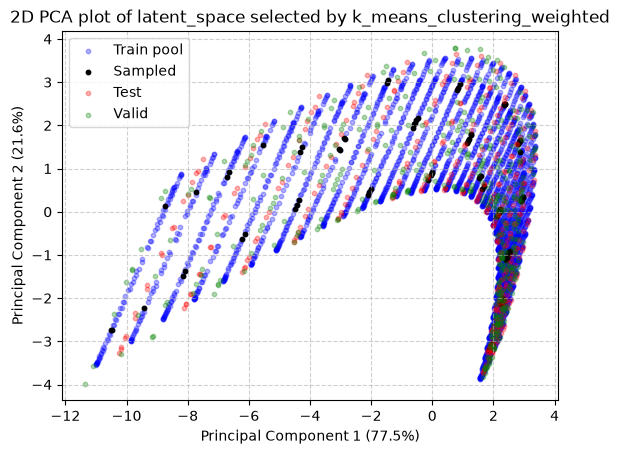

In [23]:
# 2D PCA
%matplotlib inline

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)
test_desc_matrix_scaled = StandardScaler().fit_transform(test_desc_matrix)
valid_desc_matrix_scaled = StandardScaler().fit_transform(valid_desc_matrix)

pca_2d = PCA(n_components=2)
desc_matrix_pca_2d = pca_2d.fit_transform(desc_matrix_scaled)
test_desc_matrix_pca_2d = pca_2d.fit_transform(test_desc_matrix_scaled)
valid_desc_matrix_pca_2d = pca_2d.fit_transform(valid_desc_matrix_scaled)

plt.scatter(desc_matrix_pca_2d[:,0], desc_matrix_pca_2d[:,1], color='blue', marker='o', alpha=0.3, s=10, label='Train pool')
plt.scatter(
    desc_matrix_pca_2d[sampled_idx, 0],
    desc_matrix_pca_2d[sampled_idx, 1],
    color='black',
    marker='o',
    alpha=1,
    s=10,
    label='Sampled'
)
plt.scatter(test_desc_matrix_pca_2d[:,0], test_desc_matrix_pca_2d[:,1], color='red', marker='o', alpha=0.3, s=10, label='Test')
plt.scatter(valid_desc_matrix_pca_2d[:,0], valid_desc_matrix_pca_2d[:,1], color='green', marker='o', alpha=0.3, s=10, label='Valid')

plt.title(f'2D PCA plot of {DESCRIPTOR} selected by {SELECTOR}')
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()


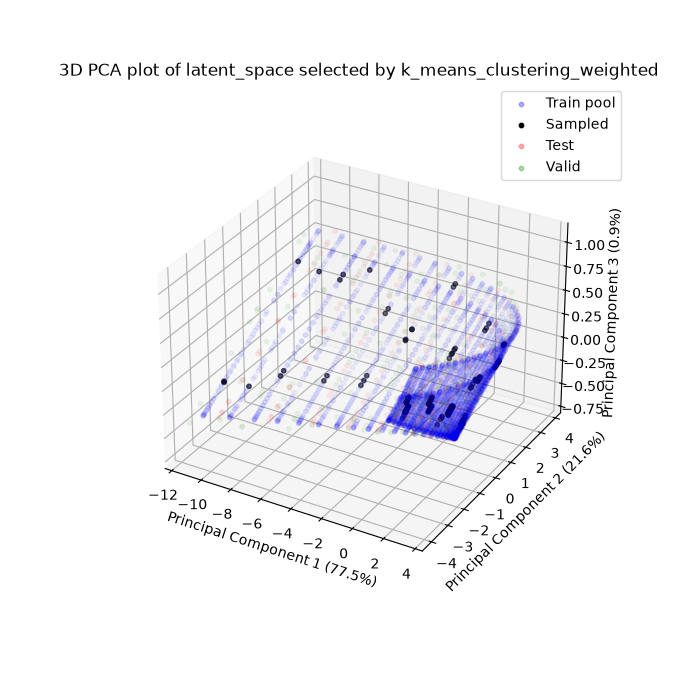

In [25]:
# 3D PCA
%matplotlib widget

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)
test_desc_matrix_scaled = StandardScaler().fit_transform(test_desc_matrix)
valid_desc_matrix_scaled = StandardScaler().fit_transform(valid_desc_matrix)

pca_3d = PCA(n_components=3)
desc_matrix_pca_3d = pca_3d.fit_transform(desc_matrix_scaled)
test_desc_matrix_pca_3d = pca_3d.fit_transform(test_desc_matrix_scaled)
valid_desc_matrix_pca_3d = pca_3d.fit_transform(valid_desc_matrix_scaled)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.85)

ax.scatter(desc_matrix_pca_3d[:,0], desc_matrix_pca_3d[:,1], desc_matrix_pca_3d[:,2], color='blue', marker='o', alpha=0.3, s=10, label="Train pool")
ax.scatter(
    desc_matrix_pca_3d[sampled_idx, 0],
    desc_matrix_pca_3d[sampled_idx, 1],
    desc_matrix_pca_3d[sampled_idx, 2],
    color='black',
    marker='o',
    alpha=1,
    s=10,
    label='Sampled'
)
ax.scatter(test_desc_matrix_pca_3d[:,0], test_desc_matrix_pca_3d[:,1], test_desc_matrix_pca_3d[:,2], color='red', marker='o', alpha=0.3, s=10, label='Test')
ax.scatter(valid_desc_matrix_pca_3d[:,0], valid_desc_matrix_pca_3d[:,1], valid_desc_matrix_pca_3d[:,2], color='green', marker='o', alpha=0.3, s=10, label='Valid')

plt.title(f'3D PCA plot of {DESCRIPTOR} selected by {SELECTOR}')
ax.set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"Principal Component 3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()


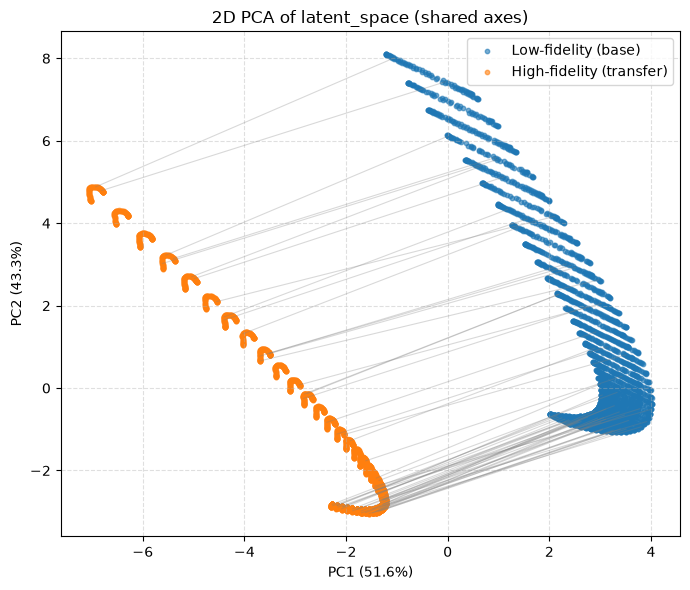

In [35]:
# 2D plot of low-fidelity vs high-fidelity 
%matplotlib inline

# Fit PCA on the combined low- and high-fidelity descriptor sets so both
# are projected onto the same 2D axes.
combined_desc = np.vstack([desc_matrix, full_desc_matrix])

scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_desc)

pca_2d = PCA(n_components=2)
combined_pca_2d = pca_2d.fit_transform(combined_scaled)

desc_pca_2d = combined_pca_2d[:len(desc_matrix)]
full_pca_2d = combined_pca_2d[len(desc_matrix):]

plt.figure(figsize=(7, 6))

plt.scatter(
    desc_pca_2d[:, 0],
    desc_pca_2d[:, 1],
    color="tab:blue",
    s=10,
    alpha=0.6,
    label="Low-fidelity (base)",
)

plt.scatter(
    full_pca_2d[:, 0],
    full_pca_2d[:, 1],
    color="tab:orange",
    s=10,
    alpha=0.6,
    label="High-fidelity (transfer)",
)

# Draw one connecting line for every 5 points to keep the plot readable.
n_points = min(len(desc_pca_2d), len(full_pca_2d))
for i in range(0, n_points, 50):
    plt.plot(
        [desc_pca_2d[i, 0], full_pca_2d[i, 0]],
        [desc_pca_2d[i, 1], full_pca_2d[i, 1]],
        color="gray",
        alpha=0.3,
        linewidth=0.8,
    )

plt.title(f"2D PCA of {DESCRIPTOR} (shared axes)")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

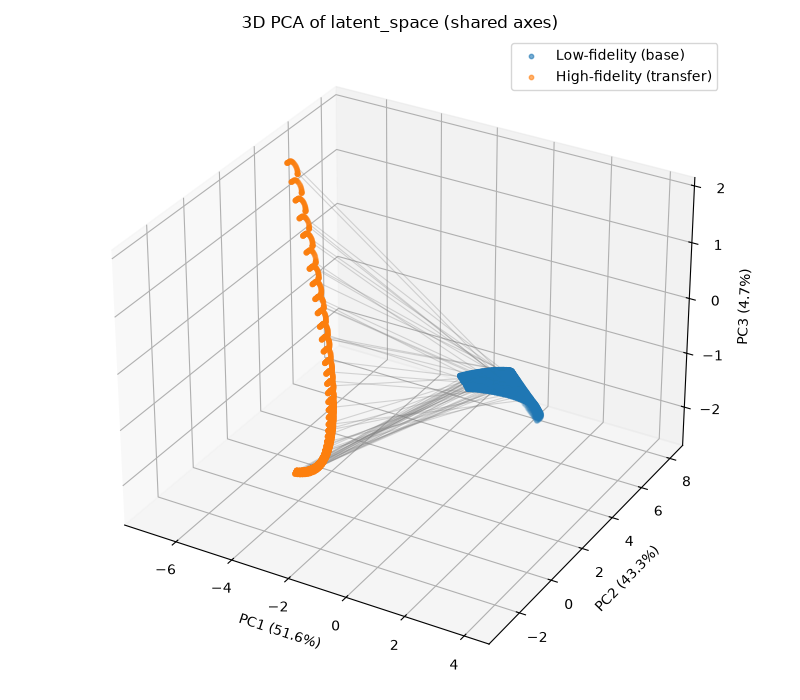

In [36]:
# 3D plot of low-fidelity vs high-fidelity 
%matplotlib widget

combined_desc = np.vstack([desc_matrix, full_desc_matrix])

scaler = StandardScaler()
combined_scaled = scaler.fit_transform(combined_desc)

pca_3d = PCA(n_components=3)
combined_pca_3d = pca_3d.fit_transform(combined_scaled)

desc_pca_3d = combined_pca_3d[:len(desc_matrix)]
full_pca_3d = combined_pca_3d[len(desc_matrix):]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    desc_pca_3d[:, 0],
    desc_pca_3d[:, 1],
    desc_pca_3d[:, 2],
    color="tab:blue",
    s=10,
    alpha=0.6,
    label="Low-fidelity (base)",
)

ax.scatter(
    full_pca_3d[:, 0],
    full_pca_3d[:, 1],
    full_pca_3d[:, 2],
    color="tab:orange",
    s=10,
    alpha=0.6,
    label="High-fidelity (transfer)",
)

n_points = min(len(desc_pca_3d), len(full_pca_3d))
for i in range(0, n_points, 50):
    ax.plot(
        [desc_pca_3d[i, 0], full_pca_3d[i, 0]],
        [desc_pca_3d[i, 1], full_pca_3d[i, 1]],
        [desc_pca_3d[i, 2], full_pca_3d[i, 2]],
        color="gray",
        alpha=0.3,
        linewidth=0.8,
    )

ax.set_title(f"3D PCA of {DESCRIPTOR} (shared axes)")
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2] * 100:.1f}%)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


## 2. Distances between points

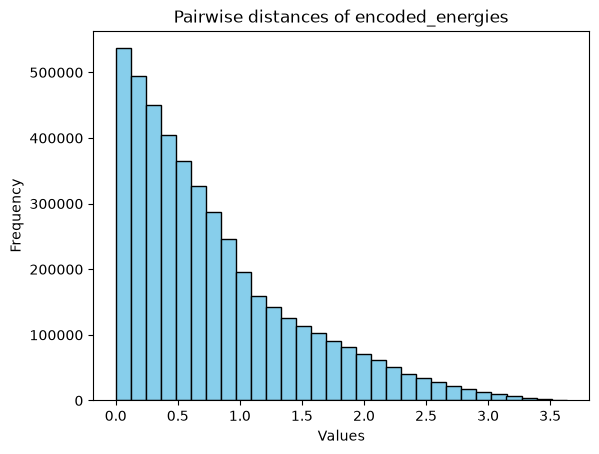

In [15]:
# Pairwise distances
%matplotlib inline

distances = pdist(desc_matrix)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Pairwise distances of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

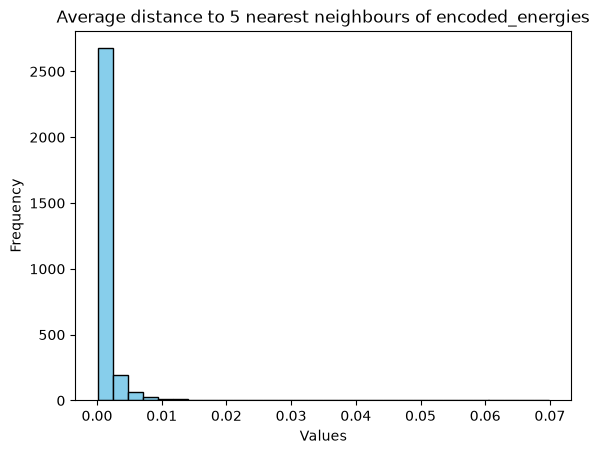

In [16]:
# Average distance to n nearest neighbours

N_NEIGHBORS = 5

nbrs = NearestNeighbors(n_neighbors=N_NEIGHBORS).fit(desc_matrix)
distances, _ = nbrs.kneighbors(desc_matrix)

avg_distances = distances.mean(axis=1)

plt.hist(avg_distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Average distance to {N_NEIGHBORS} nearest neighbours of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

## 3. Density

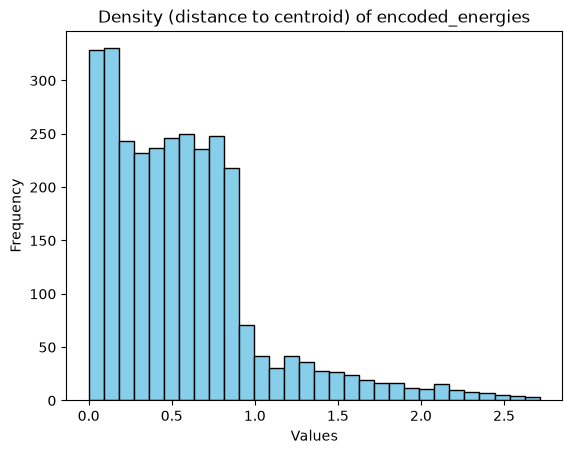

In [17]:
# Distances of all points to centroid

center = desc_matrix.mean(axis=0)
distances = np.linalg.norm(desc_matrix - center, axis=1)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Density (distance to centroid) of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()


## 4. View molecules

In [11]:
from ase.visualize import view
view(base_atoms_list)

<Popen: returncode: None args: ['/home/lim_yt/micromamba/envs/xmace311/bin/p...>